# 03_speech_conv

Purpose: generate chirplet kernels spanning the spectrum and test convolutions with a real speech signal

In [1]:
# Imports

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import soundfile as sf

from util import pchirp, pick_bw_fc, bw_fc_to_f1f2, pick_val
from util import MAX_DUR_MS, MIN_DUR_MS, MAX_DEGREE, MIN_DEGREE

%matplotlib widget

In [2]:
# Load in some speech and crop to 3s

speech_path = f'/Volumes/LPM03 storage/Datasets/Audio/LibriSpeech/LibriSpeech/train-clean-100/19/198/19-198-0010.flac'
speech_np, sr = sf.read(speech_path)
speech = torch.from_numpy(speech_np).float().unsqueeze(0)[:,:(sr *3)]

bwfc = 
    [(np.float64(412.0), np.float64(470.0)), (np.float64(1964.0), np.float64(2494.0)), (np.float64(1866.0), np.float64(4235.0))]
durs = 
    [84.90943899307145, 23.82687870557837, 98.59242643675026]
degs = 
    [0.5666384203219311, 2.0630766945048773, 1.221996037236069]
f1 = 264.0, f2 = 676.0
f1 = 3476.0, f2 = 1512.0
f1 = 5168.0, f2 = 3302.0


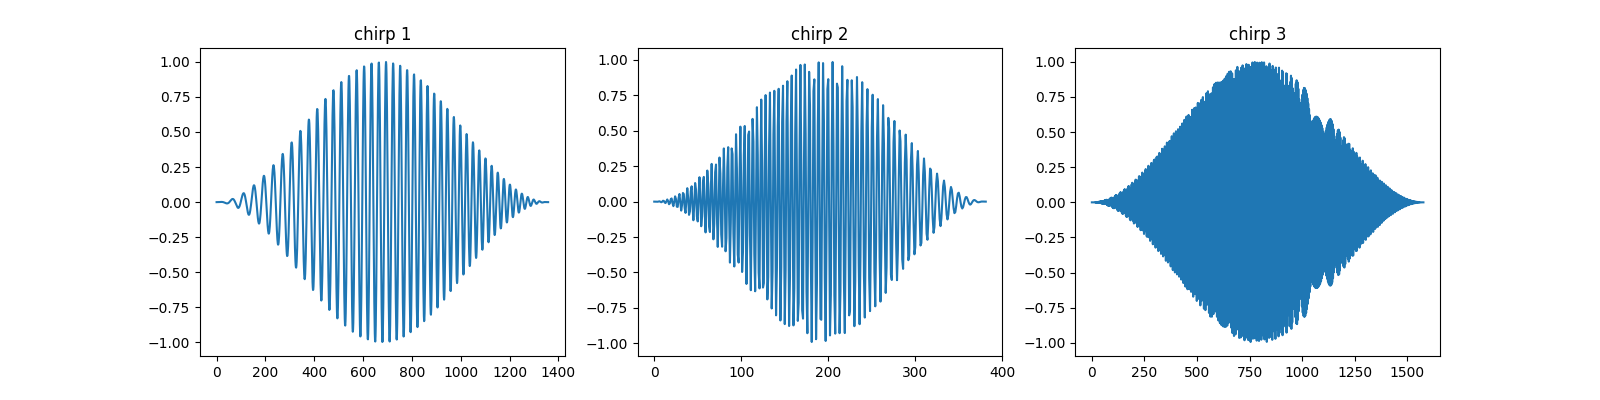

In [3]:
# Generate kernels w fc in specific ranges
ranges = [
    [200, 500],
    [1000, 2500],
    [4000, 6000]
]
bwfc = []
for rangei in ranges:
    bwi, fci = pick_bw_fc()
    while fci < rangei[0] or fci > rangei[1]:
        bwi, fci = pick_bw_fc()
    bwfc.append((np.round(bwi), np.round(fci)))
print('bwfc = ')
print('   ', bwfc)

durs = []
degs = []
for i in bwfc:
    durs.append(pick_val(MIN_DUR_MS, MAX_DUR_MS))
    degs.append(pick_val(MIN_DEGREE, MAX_DEGREE))
print('durs = ')
print('   ', durs)
print('degs = ')
print('   ', degs)

chirps = []
f1f2 = []
for i in range(len(durs)):
    f1, f2 = bw_fc_to_f1f2(bwfc[i][0], bwfc[i][1])
    f1f2.append((f1, f2))
    print(f"f1 = {f1}, f2 = {f2}")
    chirps.append(pchirp(f1, f2, durs[i], degs[i]))

plt.close('all')
figs, axs = plt.subplots(1, 3, figsize=(16, 4))
for i, ax in enumerate(axs):
    ax.plot(chirps[i])
    ax.set_title(f"chirp {i + 1}")

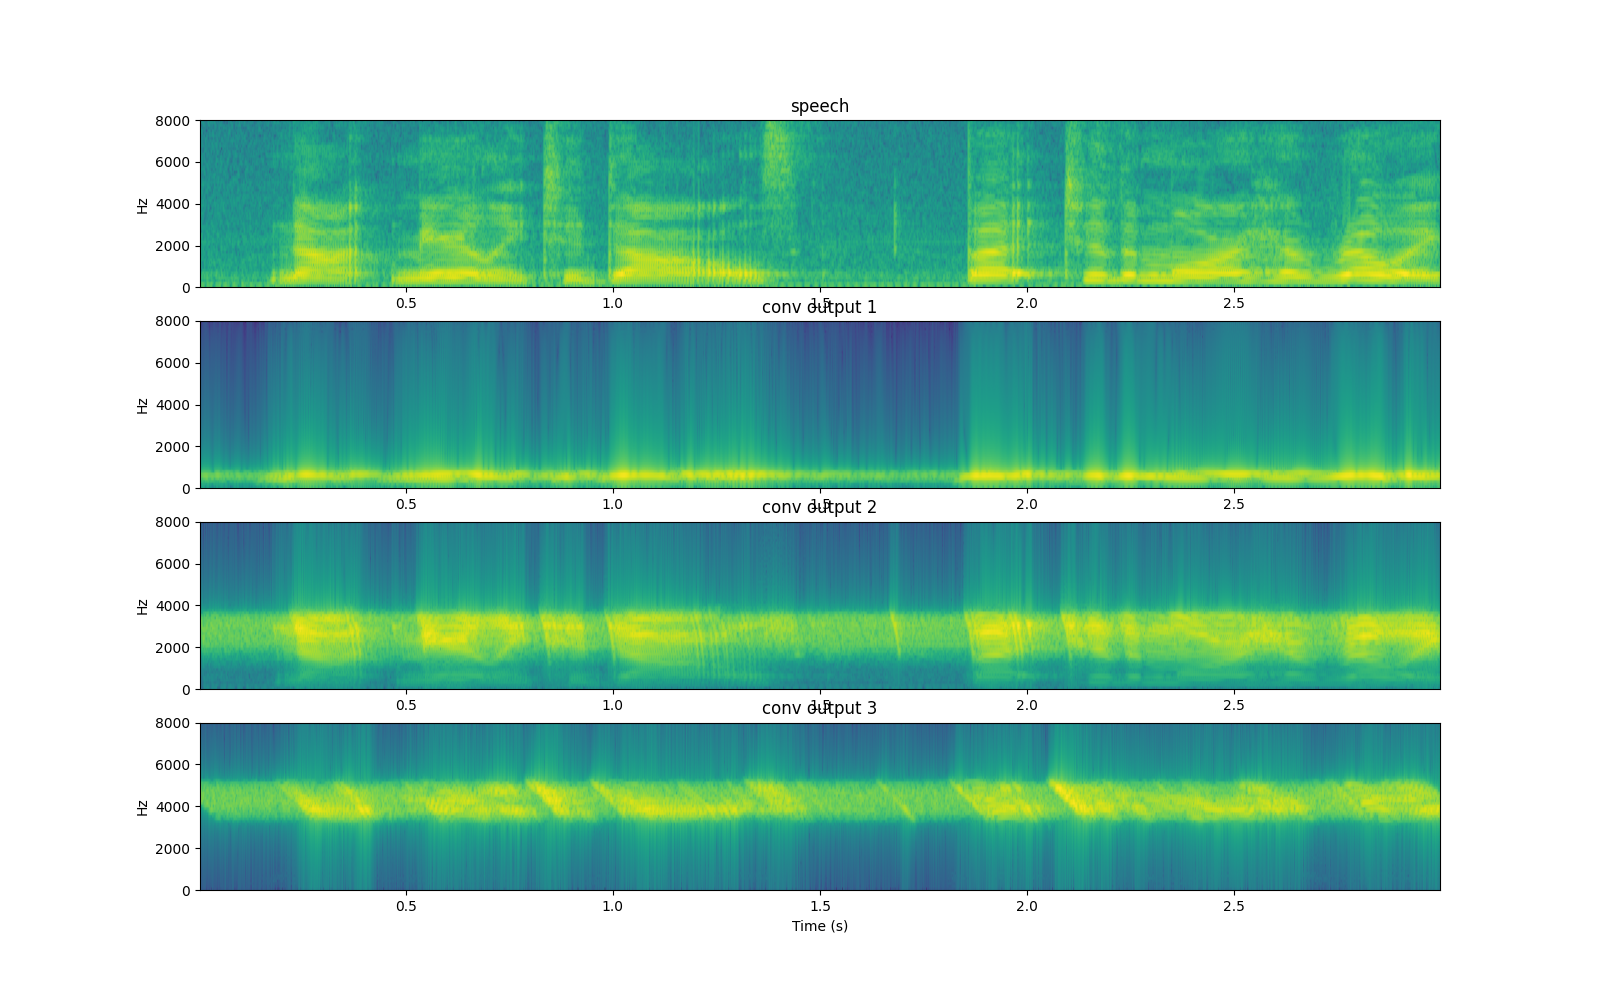

In [4]:
# Convolution and orientation check

flip_kernel = True  # if True, reverse kernel before conv1d

# conv1d expects (N, C_in, L); speech is (1, L)
x = speech.unsqueeze(1)  # (1, 1, L)

conv_outputs = []
for chirp in chirps:
    k = torch.from_numpy(chirp).float()
    if flip_kernel:
        k = k.flip(0)

    w = k.view(1, 1, -1)  # (C_out, C_in, K)
    K = w.shape[-1]
    pad_left = (K - 1) // 2
    pad_right = K - 1 - pad_left
    x_pad = F.pad(x, (pad_left, pad_right))
    y = F.conv1d(x_pad, w, stride=1)  # same: L_out = L
    assert y.shape[-1] == x.shape[-1], "Unexpected output length produced by conv1d operation"
    conv_outputs.append(y.squeeze(0).squeeze(0))  # (L_out,)

NFFT = 128
NOVERLAP = 112  # 87.5% overlap

fig, axs = plt.subplots(4, 1, figsize=(16, 10), sharex=False)
signals = [speech.squeeze().cpu().numpy()] + [y.cpu().numpy() for y in conv_outputs]
titles = ['speech'] + [f'conv output {i + 1}' for i in range(len(conv_outputs))]

for ax, sig, title in zip(axs, signals, titles):
    ax.specgram(sig, NFFT=NFFT, Fs=sr, noverlap=NOVERLAP, cmap='viridis')
    ax.set_title(title)
    ax.set_ylabel('Hz')

axs[-1].set_xlabel('Time (s)')
plt.show()

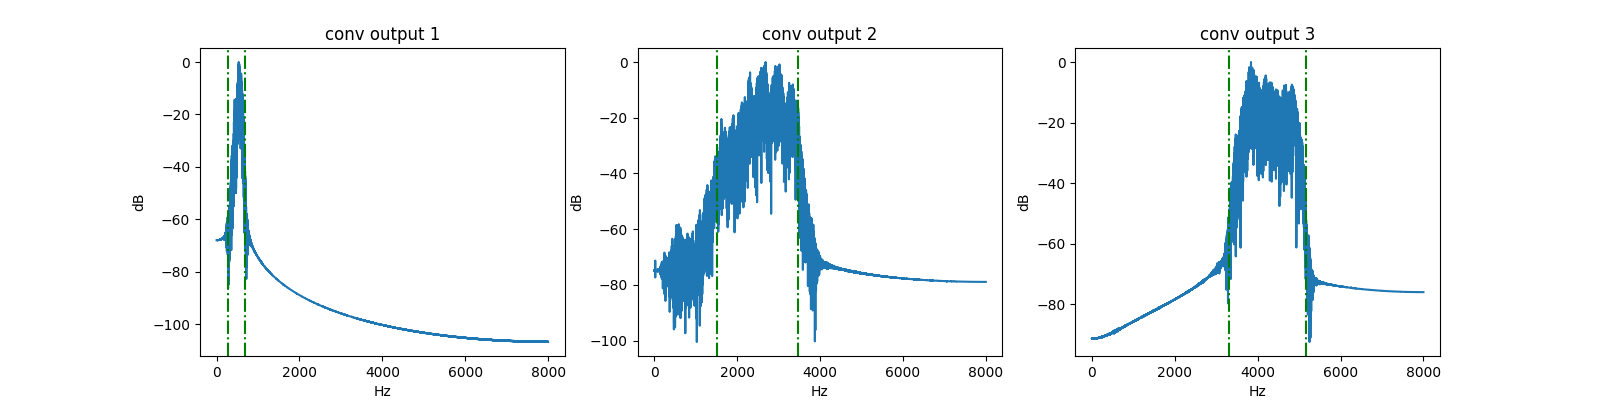

In [5]:
# FFT of conv outputs

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for i, (y, ax) in enumerate(zip(conv_outputs, axs)):
    sig = y.cpu().numpy()
    X = np.fft.rfft(sig)
    freqs = np.fft.rfftfreq(len(sig), d=1 / sr)
    mag_db = 20 * np.log10(np.abs(X) + 1e-12)
    mag_db = mag_db - np.max(mag_db)
    ax.plot(freqs[1:], mag_db[1:])  # skip DC for log-f axis
    ax.axvline(x=f1f2[i][0], color='g', linestyle='-.')
    ax.axvline(x=f1f2[i][1], color='g', linestyle='-.')
    ax.set_title(f'conv output {i + 1}')
    ax.set_xlabel('Hz')
    ax.set_ylabel('dB')

plt.show()


## Findings

- convolution operation requires proper reshaping, padding care due to even length kernels to produce 'same' outputs, flipping of kernel
- flip kernel tests w hardcoded bool show to maintain expected f1 -> f2 order, kernel requires flipping
- Spectral information shows up in expected band, though further tests will quantify leakage to ensure safe bandpass sampling